# Serve Receive Set Prediction — Exploratory Modeling
**Project:** How predictable were we in serve receive? (2025 Season)  
**Goal:** Train a multi-class classifier to predict who will be set given rotation, pass quality, and game context.  
**Split:** Train = Sets 1–3 | Test = Set 4 | Validate = Set 5

## 1. Imports & Setup

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    log_loss,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

RANDOM_STATE = 42

## 2. Load Data
CSV obtained from `extract_serve_receive.R`. Each row is one serve-receive point.

In [22]:
import subprocess

result = subprocess.run([
    "Rscript", "extract_serve_receive.R",
    "DUKE-CAL.dvw",  # arg 1: dvw path
    "249",                                              # arg 2: focus team id
    "data/cleaned_plays.csv"                           # arg 3: output path
], capture_output=True, text=True)

print(result.stdout)
if result.returncode != 0:
    print("R ERROR:", result.stderr)

Export complete: 189 rows written to data/cleaned_plays.csv 



In [23]:
df = pd.read_csv("data/cleaned_plays.csv")

print(f"Total points: {len(df)}")
print(f"Sets in file: {sorted(df['set_number'].unique())}")
print()
df.head()

Total points: 189
Sets in file: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]



,point_id,set_number,serving_team,receiving_team,home_team,visiting_team,home_team_id,visiting_team_id,home_setter_position,visiting_setter_position,home_p1,home_p2,home_p3,home_p4,home_p5,home_p6,visiting_p1,visiting_p2,visiting_p3,visiting_p4,visiting_p5,visiting_p6,home_player_id1,home_player_id2,home_player_id3,...,home_player_id6,visiting_player_id1,visiting_player_id2,visiting_player_id3,visiting_player_id4,visiting_player_id5,visiting_player_id6,server_id,serve_eval_code,receiver_id,receive_eval_code,setter_id,set_code,set_type,attacker_id,attack_code,attack_eval_code,home_score_start_of_point,visiting_score_start_of_point,score_diff,is_ace,is_overpass,out_of_system,no_set,no_attack
0,0,1,"University of California, Berkeley",Duke University,Duke University,"University of California, Berkeley",22,249,4,3,4,9,17,6,11,5,14,7,22,10,42,4,-383204,-503355,-336122,...,-503356,-550142,-379095,-550141,-542277,-379096,-542354,-550142,-,-383204,#,-512356.0,KS,B,-336122.0,X6,#,1,0,-1,False,False,False,False,False
1,1,1,Duke University,"University of California, Berkeley",Duke University,"University of California, Berkeley",22,249,3,3,9,17,6,11,5,4,14,7,22,10,42,4,-503355,-336122,-512356,...,-383204,-550142,-379095,-550141,-542277,-379096,-542354,-503355,-,-550142,+,-550141.0,KS,C,-379095.0,CF,#,1,1,0,False,False,False,False,False
2,2,1,"University of California, Berkeley",Duke University,Duke University,"University of California, Berkeley",22,249,3,2,9,17,6,11,5,4,7,22,10,42,4,14,-503355,-336122,-512356,...,-383204,-379095,-550141,-542277,-379096,-542354,-550142,-379095,-,-503355,+,-512356.0,KS,B,-336122.0,X6,#,2,1,-1,False,False,False,False,False
3,3,1,Duke University,"University of California, Berkeley",Duke University,"University of California, Berkeley",22,249,2,2,17,6,11,5,4,9,7,22,10,42,4,14,-336122,-512356,-552110,...,-503355,-379095,-550141,-542277,-379096,-542354,-550142,-336122,-,-542354,+,-550141.0,K2,F,-542277.0,X5,+,2,2,0,False,False,False,False,False
4,4,1,"University of California, Berkeley",Duke University,Duke University,"University of California, Berkeley",22,249,2,1,17,6,11,5,4,9,22,10,42,18,14,7,-336122,-512356,-552110,...,-503355,-550141,-542277,-379096,-441102,-550142,-379095,-550141,+,-503354,-,NaN,NaN,NaN,-512356.0,NaN,-,3,2,-1,False,False,True,True,False


## 3. Quick EDA
Before modeling, get a feel for the target distribution and flag any data quality issues.
From inspecting, we can see that the original data missed certain plays and had no data, so some counts are different

In [24]:
#  points per set 
print("Points per set:")
print(df['set_number'].value_counts().sort_index())
print()

# special situation rates
print("Special situation counts:")
for flag in ['is_ace', 'is_overpass', 'out_of_system', 'no_set', 'no_attack']:
    print(f"  {flag}: {df[flag].sum()}")
print()

#  receive quality distribution
print("Receive eval codes:")
print(df['receive_eval_code'].value_counts())

Points per set:
set_number
1    37
2    39
3    41
4    49
5    23
Name: count, dtype: int64

Special situation counts:
  is_ace: 15
  is_overpass: 22
  out_of_system: 81
  no_set: 24
  no_attack: 29

Receive eval codes:
receive_eval_code
+    68
-    50
!    31
#    18
=    15
/     7
Name: count, dtype: int64


In [25]:
# target distribution: who gets set? ---
# attacker_id is our prediction target
# exclude points with no attack (overpass, setter error, etc.)

df_model = df[df['no_attack'] == False].copy()
print(f"Rows after dropping no-attack points: {len(df_model)}")
print()
print("Attack distribution by attacker_id:")
print(df_model['attacker_id'].value_counts())

Rows after dropping no-attack points: 160

Attack distribution by attacker_id:
attacker_id
-379097.0    23
-379095.0    18
-552110.0    18
-503355.0    18
-336122.0    14
-441102.0    14
-503356.0    14
-552112.0    13
-542277.0    10
-379096.0     9
-550140.0     3
-429606.0     3
-512356.0     2
-550141.0     1
Name: count, dtype: int64


In [26]:
# receiving team rotation distribution ---
# setter_position tells us which rotation the receiving team is in

print("Home setter position distribution:")
print(df_model['home_setter_position'].value_counts().sort_index())
print()
print("Visiting setter position distribution:")
print(df_model['visiting_setter_position'].value_counts().sort_index())

Home setter position distribution:
home_setter_position
1    30
2    35
3    21
4    26
5    25
6    23
Name: count, dtype: int64

Visiting setter position distribution:
visiting_setter_position
1    22
2    26
3    31
4    23
5    34
6    24
Name: count, dtype: int64


## 4. Feature Engineering

For this first pass we keep features simple and interpretable:
- **Rotation** of the receiving team (determines hitter options)
- **Pass quality** (receive_eval_code mapped to numeric)
- **Score differential** (game pressure)
- **Set number** (fatigue, momentum, adjustment)
- **Server ID** (serving tendencies may influence receive)

In [27]:
# set to the team you want to model ---
FOCUS_TEAM = "University of California, Berkeley" 

# filter to only points where focus team is receiving
df_focus = df_model[df_model['receiving_team'] == FOCUS_TEAM].copy()
print(f"Number of points where {FOCUS_TEAM} is receiving: {len(df_focus)}")

Number of points where University of California, Berkeley is receiving: 78


In [28]:
# map receive_eval_code to numeric pass quality ---
# standard rating:  # perfect (4) 
#                   + positive (3)
#                   ! ok (2)     
#                   - negative (1)
#                   / overpass (0.5)
#                   = aced/error (0)

pass_quality_map = {
    '#': 4,
    '+': 3,
    '!': 2,
    '-': 1,
    '/': 0.5,
    '=': 0
}

df_focus['pass_quality'] = df_focus['receive_eval_code'].map(pass_quality_map)

# flag if any codes didn't map (worth knowing about)
unmapped = df_focus['pass_quality'].isna().sum()
if unmapped > 0:
    print(f"Warning: {unmapped} rows with unmapped receive_eval_code:")
    print(df_focus[df_focus['pass_quality'].isna()]['receive_eval_code'].value_counts())
else:
    print("All receive codes mapped successfully.")

All receive codes mapped successfully.


In [29]:
# --- derive receiving team's rotation ---
# setter_position in DataVolley = position on court (1-6), NOT rotation number
# American convention mapping: setter position -> team rotation

setter_to_rotation = {1: 1, 6: 2, 5: 3, 4: 4, 3: 5, 2: 6}

setter_position = np.where(
    df_focus['receiving_team'] == df_focus['home_team'],
    df_focus['home_setter_position'],
    df_focus['visiting_setter_position']
)

df_focus['receiving_rotation'] = pd.Series(setter_position, index=df_focus.index).map(setter_to_rotation)

print("Receiving rotation distribution:")
print(df_focus['receiving_rotation'].value_counts().sort_index())

Receiving rotation distribution:
receiving_rotation
1     9
2    13
3    18
4    10
5    16
6    12
Name: count, dtype: int64


In [30]:
# --- encode attacker_id as target label ---
# LabelEncoder converts player IDs to 0-indexed integers for XGBoost

le = LabelEncoder()
df_focus['target'] = le.fit_transform(df_focus['attacker_id'].astype(str))

print("Target classes (attacker_id -> label):")
for label, player_id in enumerate(le.classes_):
    count = (df_focus['target'] == label).sum()
    print(f"  Label {label} -> player_id {player_id}  ({count} times set)")

Target classes (attacker_id -> label):
  Label 0 -> player_id -379095.0  (18 times set)
  Label 1 -> player_id -379096.0  (9 times set)
  Label 2 -> player_id -379097.0  (23 times set)
  Label 3 -> player_id -441102.0  (14 times set)
  Label 4 -> player_id -542277.0  (10 times set)
  Label 5 -> player_id -550140.0  (3 times set)
  Label 6 -> player_id -550141.0  (1 times set)


In [31]:
# --- encode server_id as categorical integer ---
le_server = LabelEncoder()
df_focus['server_encoded'] = le_server.fit_transform(df_focus['server_id'].astype(str))

# --- final feature set for this first pass ---
FEATURES = [
    'receiving_rotation',  # which rotation the receiving team is in (1-6)
    'pass_quality',        # numeric pass quality (0-4)
    'score_diff',          # score differential from focus team perspective
    'set_number',          # which set of the match (1-5)
    'server_encoded',      # who is serving
]

TARGET = 'target'

# drop any rows with NaN in features
df_focus = df_focus.dropna(subset=FEATURES + [TARGET])
print(f"Final modeling rows: {len(df_focus)}")
print()
print(df_focus[FEATURES].describe())

Final modeling rows: 78

       receiving_rotation  pass_quality  score_diff  set_number  server_encoded
count           78.000000     78.000000   78.000000   78.000000       78.000000
mean             3.602564      2.461538   -1.307692    2.923077        3.884615
std              1.622406      1.028077    5.190670    1.365334        2.368521
min              1.000000      1.000000  -14.000000    1.000000        0.000000
25%              2.000000      2.000000   -4.000000    2.000000        3.000000
50%              3.000000      3.000000   -0.500000    3.000000        4.000000
75%              5.000000      3.000000    2.750000    4.000000        5.750000
max              6.000000      4.000000    8.000000    5.000000        8.000000


## 5. Train / Test / Validate Split
- **Train:** Sets 1–3 (model learns tendencies)
- **Test:** Set 4 (tune and evaluate)
- **Validate:** Set 5 (final held-out check — don't peek until the end)

In [32]:
train = df_focus[df_focus['set_number'].isin([1, 2, 3])]
test  = df_focus[df_focus['set_number'] == 4]
val   = df_focus[df_focus['set_number'] == 5]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]

print(f"Train: {len(X_train)} points (sets 1-3)")
print(f"Test:  {len(X_test)}  points (set 4)")
print(f"Val:   {len(X_val)}   points (set 5)")

Train: 46 points (sets 1-3)
Test:  22  points (set 4)
Val:   10   points (set 5)


## 6. Baseline Model — XGBoost
First pass with sensible defaults. We'll tune later once we confirm the pipeline runs end-to-end.

In [33]:
model = XGBClassifier(
    n_estimators    = 100,
    max_depth       = 3,       # shallow trees — small dataset, avoids overfitting
    learning_rate   = 0.1,
    use_label_encoder = False,
    eval_metric     = 'mlogloss',
    random_state    = RANDOM_STATE
)

model.fit(X_train, y_train)

/Users/lylatraylor/sr-predict-proj/SR-prediction/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:44:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [34]:
# --- evaluate on test set (set 4) ---
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print("=== Test Set (Set 4) Performance ===")
print()
print(classification_report(
    y_test, y_pred,
    target_names=[f"player_{c}" for c in le.classes_]
))
print(f"Log Loss: {log_loss(y_test, y_pred_proba):.4f}")

=== Test Set (Set 4) Performance ===

                  precision    recall  f1-score   support

player_-379095.0       0.43      1.00      0.60         3
player_-379096.0       0.40      1.00      0.57         2
player_-379097.0       1.00      0.22      0.36         9
player_-441102.0       0.25      0.33      0.29         3
player_-542277.0       0.67      0.50      0.57         4
player_-550140.0       0.00      0.00      0.00         0
player_-550141.0       0.00      0.00      0.00         1

        accuracy                           0.45        22
       macro avg       0.39      0.44      0.34        22
    weighted avg       0.66      0.45      0.43        22

Log Loss: 1.4611


/Users/lylatraylor/sr-predict-proj/SR-prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lylatraylor/sr-predict-proj/SR-prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lylatraylor/sr-predict-proj/SR-prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beh

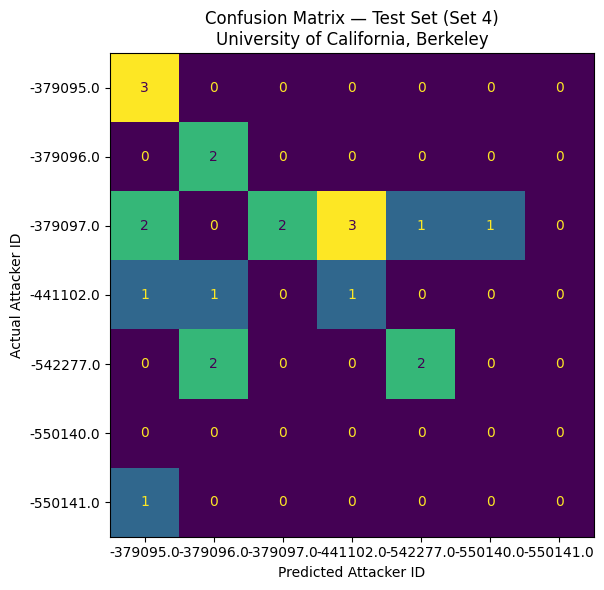

In [35]:
# --- confusion matrix ---
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    ax=ax,
    colorbar=False
)
ax.set_title(f"Confusion Matrix — Test Set (Set 4)\n{FOCUS_TEAM}")
ax.set_xlabel("Predicted Attacker ID")
ax.set_ylabel("Actual Attacker ID")
plt.tight_layout()
plt.show()

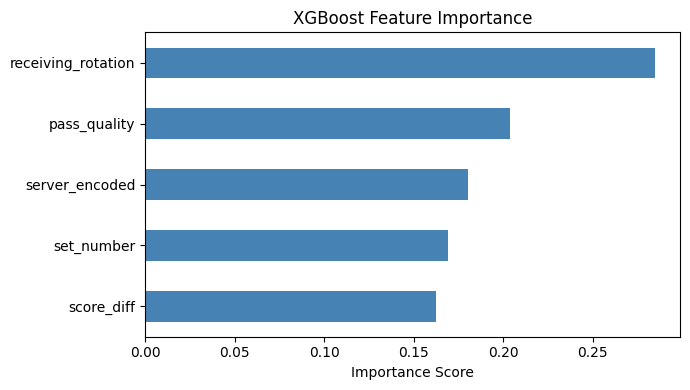

In [36]:
# --- feature importance ---
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("XGBoost Feature Importance")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [37]:
# --- example: probability output for a single point ---
# This is what the model would output in a live scouting context

sample = X_test.iloc[[0]]
probs  = model.predict_proba(sample)[0]

print("Example prediction for one point:")
print(f"  Features: {sample.to_dict(orient='records')[0]}")
print()
print("  Probability each attacker is set:")
for player_id, prob in zip(le.classes_, probs):
    bar = '█' * int(prob * 40)
    print(f"  player {player_id:>12}  {prob:.1%}  {bar}")

Example prediction for one point:
  Features: {'receiving_rotation': 3, 'pass_quality': 1.0, 'score_diff': 1, 'set_number': 4, 'server_encoded': 3}

  Probability each attacker is set:
  player    -379095.0  3.4%  █
  player    -379096.0  1.8%  
  player    -379097.0  17.3%  ██████
  player    -441102.0  73.5%  █████████████████████████████
  player    -542277.0  2.8%  █
  player    -550140.0  1.2%  


## 7. Next Steps

Once this baseline is running, the natural progression is:

1. **Multi-match training** — loop `extract_serve_receive.R` across the full season and concatenate CSVs, then use leave-one-match-out or chronological CV instead of set-based splits
2. **Richer features** — which specific hitters are *on the court* in each rotation (from the `home_player_id` / `visiting_player_id` columns), in-system vs out-of-system as a binary flag
3. **Hierarchical target** — first predict broad zone (outside / middle / right / back), then predict specific set type within zone
4. **Calibration check** — are the predicted probabilities actually trustworthy? (Brier score, reliability diagrams)
5. **Rotation-by-rotation breakdown** — where is the team most vs least predictable?